<a href="https://colab.research.google.com/github/gabiuxo/Algoritmos-de-Aprendizaje-Automatico/blob/main/Practica_Jueves_Tema9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica del jueves - Selección y transformación de características

**Nombre:** Gabriel Elizondo Martinez  
**Matrícula:** AL07009102  
**Tema 9:** RFE, PCA y LDA


## Reto 1. Simulación manual de una ronda de RFE

Ordené las variables de mayor a menor importancia e identifiqué la de menor valor para eliminarla en la primera iteración.


In [1]:
# define the simulated feature importances
feature_importance = {"V1": 0.8, "V2": 0.1, "V3": 0.5, "V4": 0.6}

# sort features from highest to lowest importance
ordered_features = sorted(
    feature_importance.items(),
    key=lambda item: item[1],
    reverse=True,
)

# identify and remove the least important feature
feature_to_remove = min(feature_importance, key=feature_importance.get)
remaining_features = [
    feature for feature in feature_importance
    if feature != feature_to_remove
]

print("Orden de importancia:", ordered_features)
print("Variable eliminada:", feature_to_remove)
print("Subconjunto resultante:", remaining_features)


Orden de importancia: [('V1', 0.8), ('V4', 0.6), ('V3', 0.5), ('V2', 0.1)]
Variable eliminada: V2
Subconjunto resultante: ['V1', 'V3', 'V4']


El orden obtenido fue **V1 > V4 > V3 > V2**. Eliminé **V2** porque tuvo la menor importancia, con 0.1. El subconjunto resultante fue **{V1, V3, V4}**.


## Reto 2. Implementación de RFE con Scikit-Learn

Generé un conjunto de clasificación con seis características y utilicé regresión logística como estimador de RFE para conservar las tres variables más relevantes.


In [2]:
import numpy as np

from sklearn.datasets import make_classification
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# create a classification dataset with six features
x, y = make_classification(
    n_samples=100,
    n_features=6,
    n_informative=4,
    random_state=42,
)
feature_names = np.array([f"V{i}" for i in range(1, 7)])

# select three features with recursive feature elimination
estimator = LogisticRegression(random_state=42, max_iter=1000)
selector = RFE(estimator, n_features_to_select=3)
selector.fit(x, y)

selected_features = feature_names[selector.support_]

print("Máscara de selección:", selector.support_)
print("Ranking:", selector.ranking_)
print("Características seleccionadas:", selected_features)


Máscara de selección: [False  True False  True False  True]
Ranking: [2 1 3 1 4 1]
Características seleccionadas: ['V2' 'V4' 'V6']


RFE seleccionó **V2, V4 y V6**. La máscara muestra con `True` las variables conservadas y el ranking 1 identifica las características seleccionadas.


## Reto 3. Proyección PCA y varianza explicada

Estandaricé las cuatro variables del conjunto Iris y apliqué PCA con dos componentes. Después calculé la varianza explicada por cada componente y la varianza acumulada.


In [3]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# load and standardize the iris dataset
iris = load_iris()
x_scaled = StandardScaler().fit_transform(iris.data)

# reduce the dataset to two principal components
pca = PCA(n_components=2)
z_pca = pca.fit_transform(x_scaled)
pca_cumulative_variance = pca.explained_variance_ratio_.sum()

print("Dimensiones de PCA:", z_pca.shape)
print("Varianza explicada por componente:", pca.explained_variance_ratio_)
print(f"Varianza acumulada: {pca_cumulative_variance * 100:.2f}%")


Dimensiones de PCA: (150, 2)
Varianza explicada por componente: [0.72962445 0.22850762]
Varianza acumulada: 95.81%


Los dos componentes conservaron aproximadamente **95.81% de la varianza total**. El primer componente explicó cerca de 72.96% y el segundo 22.85%.


## Reto 4. Proyección supervisada con LDA

Apliqué LDA con dos componentes utilizando las características y las etiquetas de Iris. Como existen tres clases, el máximo permitido es dos componentes, es decir, C - 1.


In [4]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# project iris into two supervised discriminant components
lda = LinearDiscriminantAnalysis(n_components=2)
z_lda = lda.fit_transform(iris.data, iris.target)

print("Dimensiones originales:", iris.data.shape)
print("Dimensiones proyectadas por LDA:", z_lda.shape)


Dimensiones originales: (150, 4)
Dimensiones proyectadas por LDA: (150, 2)


La proyección transformó los datos de **150 filas y 4 variables** a **150 filas y 2 componentes discriminantes**.


## Reto 5. Comparación entre PCA y LDA

Comparé visualmente las proyecciones y calculé una razón de separación dividiendo la dispersión entre clases entre la dispersión interna de las clases. Un resultado mayor representa grupos más separados.


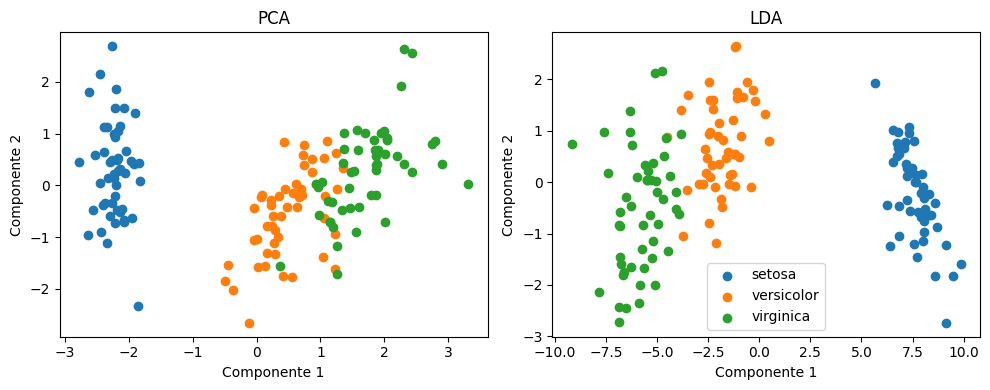

Razón de separación con PCA: 3.0199
Razón de separación con LDA: 16.2387


In [5]:
import matplotlib.pyplot as plt


def separation_ratio(z, labels):
    # compare between-class and within-class dispersion
    global_mean = z.mean(axis=0)
    between_dispersion = 0.0
    within_dispersion = 0.0

    for class_id in np.unique(labels):
        class_data = z[labels == class_id]
        class_mean = class_data.mean(axis=0)
        between_dispersion += len(class_data) * np.sum(
            (class_mean - global_mean) ** 2
        )
        within_dispersion += np.sum((class_data - class_mean) ** 2)

    return between_dispersion / within_dispersion


# calculate numeric class separation
pca_separation = separation_ratio(z_pca, iris.target)
lda_separation = separation_ratio(z_lda, iris.target)

# compare both two-dimensional projections
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for class_id, class_name in enumerate(iris.target_names):
    mask = iris.target == class_id
    axes[0].scatter(z_pca[mask, 0], z_pca[mask, 1], label=class_name)
    axes[1].scatter(z_lda[mask, 0], z_lda[mask, 1], label=class_name)

axes[0].set_title("PCA")
axes[0].set_xlabel("Componente 1")
axes[0].set_ylabel("Componente 2")
axes[1].set_title("LDA")
axes[1].set_xlabel("Componente 1")
axes[1].set_ylabel("Componente 2")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Razón de separación con PCA: {pca_separation:.4f}")
print(f"Razón de separación con LDA: {lda_separation:.4f}")


LDA presentó una razón de separación mayor que PCA: **16.2387 frente a 3.0199**. También observé una separación más clara entre las tres especies en su proyección.

Si mi objetivo principal fuera clasificar nuevas muestras y tuviera etiquetas disponibles, elegiría **LDA**, porque utiliza las clases para maximizar su separación. Elegiría **PCA** si necesitara reducir dimensiones sin utilizar etiquetas o explorar la estructura general de los datos.
